In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



%matplotlib inline

In [6]:
df=pd.read_csv('Airquality_Data.csv')

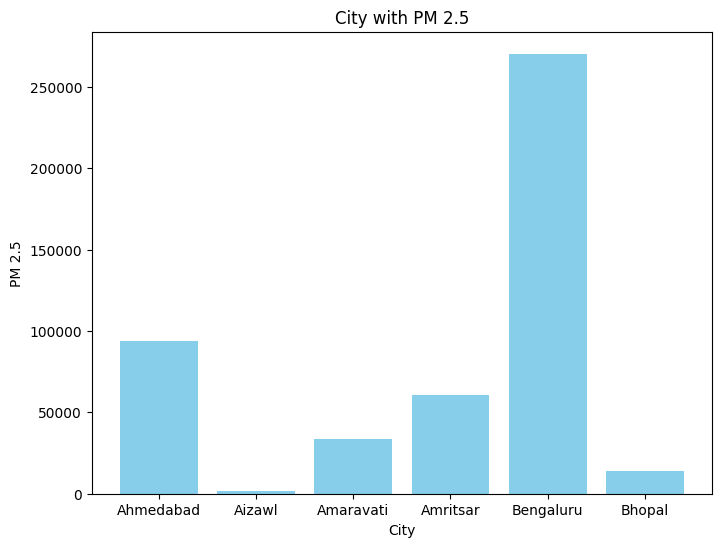

In [7]:
city_pm1 = df.groupby('City') ['PM2.5'].sum().head(6)
plt.figure(figsize=(8,6))
plt.bar(city_pm1.index, city_pm1.values, color='skyblue')
plt.xlabel('City')
plt.ylabel('PM 2.5')
plt.title('City with PM 2.5')

plt.show()

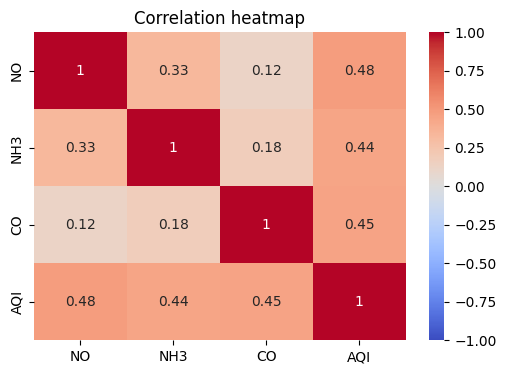

In [8]:
corr = df[['NO', 'NH3', 'CO','AQI']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap')
plt.show()


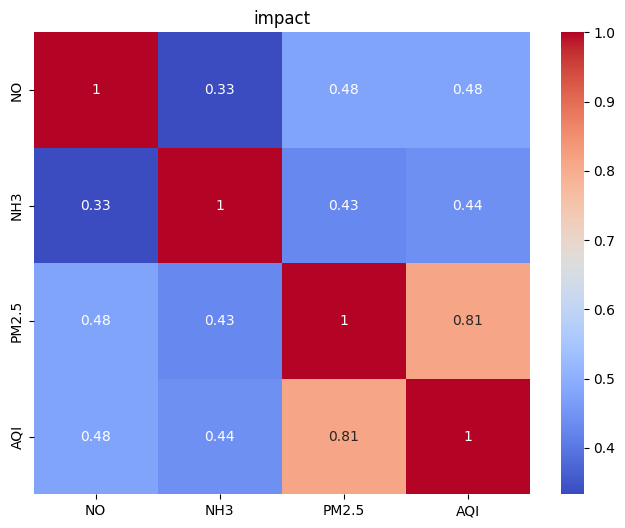

In [9]:
pol=['NO', 'NH3', 'PM2.5']
df=df[pol + ['AQI']]
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('impact')
plt.show()

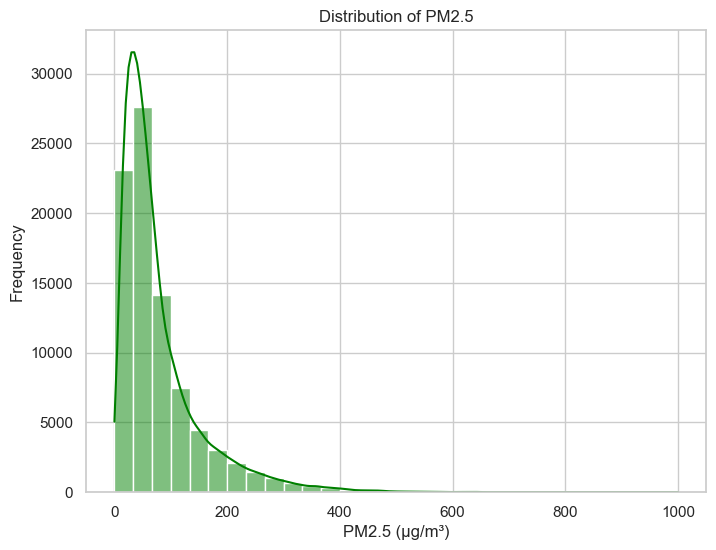

In [10]:
sns.set(style="whitegrid")

# Distribution of PM2.5
plt.figure(figsize=(8, 6))
sns.histplot(df['PM2.5'], bins=30, kde=True, color='green')
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.show()

In [11]:
numerical_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO','AQI']

correlation = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Pollutants and AQI')
plt.show()

KeyError: "['PM10', 'NO2', 'NOx', 'CO'] not in index"

In [12]:

plt.figure(figsize=(8, 6))
sns.countplot(x='AQI_Bucket', data=df, order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor'])
plt.title('Distribution of AQI Buckets')
plt.xlabel('AQI Bucket')
plt.ylabel('Count')
plt.show()

ValueError: Could not interpret value `AQI_Bucket` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['PM2.5', 'PM10', 'NO2', 'O3']])
plt.title('Box Plot of Key Pollutants')
plt.ylabel('Concentration (µg/m³)')
plt.show()

KeyError: "['PM10', 'NO2', 'O3'] not in index"

<Figure size 1000x600 with 0 Axes>

In [14]:
from scipy.stats import shapiro

# Shapiro-Wilk test for PM2.5
stat, p = shapiro(df['PM2.5'])
print("Shapiro-Wilk Test for PM2.5:")
print(f"Statistic: {stat:.4f}, p-value: {p:.4f}")
print("PM2.5 is" + ("" if p > 0.05 else " not") + " normally distributed.")

Shapiro-Wilk Test for PM2.5:
Statistic: nan, p-value: nan
PM2.5 is not normally distributed.


In [15]:
sns.set(style="whitegrid")
key_pollutants = ['PM2.5', 'PM10', 'NO2', 'O3']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[key_pollutants])
plt.title('Box Plot of Key Pollutants')
plt.ylabel('Concentration (µg/m³)')
plt.show()

KeyError: "['PM10', 'NO2', 'O3'] not in index"

<Figure size 1000x600 with 0 Axes>

In [21]:
from scipy.stats import ttest_ind
pm25_2017 =df[df['Date'].dt.year == 2017]['PM2.5']
pm25_2018 = df[df['Date'].dt.year == 2018]['PM2.5']
t_stat, p_val = ttest_ind(pm25_2017, pm25_2018, equal_var=False)
print("T-test for PM2.5 (2017 vs 2018):")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
print("Difference is" + ("" if p_val < 0.05 else " not") + " significant.")

KeyError: 'Date'

In [22]:
from scipy.stats import norm
known_mean = 25
sample_mean = df['PM2.5'].mean()
sample_std = df['PM2.5'].std()
n = len(df['PM2.5'])
z_stat = (sample_mean - known_mean) / (sample_std / np.sqrt(n))
p_val = 2 * (1 - norm.cdf(abs(z_stat)))
print("Z-test for PM2.5 against WHO guideline (25 µg/m³):")
print(f"Z-statistic: {z_stat:.4f}, p-value: {p_val:.4f}")

Z-test for PM2.5 against WHO guideline (25 µg/m³):
Z-statistic: 237.3999, p-value: 0.0000


In [25]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['City'], df['AQI_Binary'])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
print("Chi-Squared Test for AQI_Bucket vs Season:")
print(f"Chi2 Statistic: {chi2_stat:.4f}, p-value: {p_val:.4f}, DoF: {dof}")

KeyError: 'City'

In [27]:
plt.figure(figsize=(8, 6))
sns.countplot(x='AQI_Bucket', data=df, order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor'])
plt.title('Distribution of AQI Buckets')
plt.xlabel('AQI Bucket')
plt.ylabel('Count')
plt.show()

ValueError: Could not interpret value `AQI_Bucket` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [28]:
key_pollutants = ['PM2.5', 'PM10', 'NO2', 'O3']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[key_pollutants])
plt.title('Box Plot of Key Pollutants')
plt.ylabel('Concentration (µg/m³)')
plt.show()

KeyError: "['PM10', 'NO2', 'O3'] not in index"

<Figure size 1000x600 with 0 Axes>

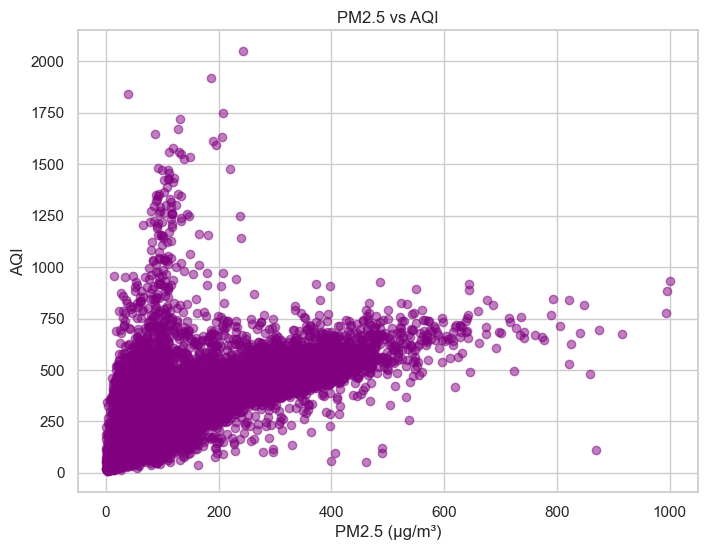

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(df['PM2.5'], df['AQI'], color='purple', alpha=0.5)
plt.title('PM2.5 vs AQI')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('AQI')
plt.show()

In [31]:
aqi_bucket_counts = df['AQI_Bucket'].value_counts()
print("Count of Days per AQI_Bucket:")
print(aqi_bucket_counts)

KeyError: 'AQI_Bucket'

In [32]:
aqi_bucket_counts = df['AQI_Bucket'].value_counts()
avg_aqi_bucket_count = aqi_bucket_counts.mean()

print("AQI_Bucket Counts:")
print(aqi_bucket_counts)
print(f"Average Count of Days per AQI_Bucket: {avg_aqi_bucket_count:.2f}")

KeyError: 'AQI_Bucket'